In [99]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from roar import ALL_VEHICLES, MEASUREMENTS, ROOT_DIR, VEHICLE_COLORS

sns.set_style("whitegrid")
sns.set_palette("husl")

In [100]:
# FILE_PATH = "measure_logo_results.csv"
FILE_PATH = ROOT_DIR / "results" / "vehicle_logo_results.csv"

In [101]:
df = pl.read_csv(FILE_PATH)

if FILE_PATH.stem.startswith("measure_logo"):
    LOGO_GROUP = "measure"
    idx2name = {idx: measure for idx, measure in enumerate(MEASUREMENTS)}
    SPLIT_ORDER = MEASUREMENTS
    SPLIT_PALETTE = None
elif FILE_PATH.stem.startswith("vehicle_logo"):
    LOGO_GROUP = "vehicle"
    idx2name = {idx: vehicle for idx, vehicle in enumerate(ALL_VEHICLES)}
    SPLIT_ORDER = ALL_VEHICLES
    SPLIT_PALETTE = VEHICLE_COLORS

In [102]:
df.sort("mean_test_weighted_f1", descending=True).select(
    ["mean_test_weighted_f1", "model", "param_feature_selector__feature_set"]
).head(10)

mean_test_weighted_f1,model,param_feature_selector__feature_set
f64,str,str
0.884856,"""tabpfn_emb_rf""","""cleaned"""
0.884321,"""tabpfn_emb_log_reg""","""cleaned"""
0.880921,"""tabpfn_emb_log_reg""","""cleaned"""
0.879233,"""tabpfn_emb_log_reg""","""cleaned"""
0.875936,"""tabpfn_emb_log_reg""","""cleaned"""
0.874041,"""tabpfn_emb_log_reg""","""cleaned"""
0.869037,"""tabpfn_emb_log_reg""","""cleaned"""
0.86818,"""tabpfn_emb_log_reg""","""cleaned"""
0.867221,"""tabpfn_emb_log_reg""","""cleaned"""


## Feature Set

In [103]:
tbl = (
    df.filter(pl.col("rank_test_weighted_f1") == 1)
    .sort("mean_test_weighted_f1", descending=True)
    .unique("model", keep="first")
    .select(
        ["model", "mean_test_weighted_f1", "std_test_weighted_f1", "mean_test_acc", "std_test_acc"]
    )
)
for row in tbl.iter_rows():
    print(f"Model: {row[0]}, F1: {row[1]:.2f} ± {row[2]:.2f}, Acc: {row[3]:.2f} ± {row[4]:.2f}")

Model: tabpfn_emb_xgb, F1: 0.76 ± 0.14, Acc: 0.81 ± 0.10
Model: tabpfn, F1: 0.84 ± 0.10, Acc: 0.85 ± 0.09
Model: tabpfn_emb_lgbm, F1: 0.86 ± 0.06, Acc: 0.87 ± 0.05
Model: log_reg, F1: 0.83 ± 0.06, Acc: 0.83 ± 0.06
Model: xgb, F1: 0.73 ± 0.21, Acc: 0.79 ± 0.14
Model: dummy, F1: 0.61 ± 0.15, Acc: 0.72 ± 0.11
Model: tabpfn_emb_svc, F1: 0.81 ± 0.21, Acc: 0.85 ± 0.15
Model: tabpfn_emb_rf, F1: 0.88 ± 0.07, Acc: 0.89 ± 0.06
Model: lgbm, F1: 0.75 ± 0.16, Acc: 0.79 ± 0.11
Model: tabpfn_emb_log_reg, F1: 0.88 ± 0.05, Acc: 0.88 ± 0.04
Model: svc, F1: 0.75 ± 0.12, Acc: 0.80 ± 0.10
Model: rf, F1: 0.73 ± 0.16, Acc: 0.77 ± 0.10


In [104]:
best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_weighted_f1$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_acc$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)

all_metrics = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"))
    .with_columns(pl.col("split").replace_strict(idx2name).alias("leave_out_group"))
)

In [105]:
best_models_f1.unique(["model", "param_feature_selector__feature_set"])

model,param_feature_selector__feature_set,split,score,metric
str,str,str,f64,str
"""xgb""","""cleaned_invariant""","""split0_test_weighted_f1""",0.45,"""weighted_f1"""
"""tabpfn""","""cleaned""","""split0_test_weighted_f1""",0.607018,"""weighted_f1"""
"""tabpfn""","""cleaned_invariant+speed""","""split0_test_weighted_f1""",0.728571,"""weighted_f1"""
"""lgbm""","""basic""","""split0_test_weighted_f1""",0.45,"""weighted_f1"""
"""log_reg""","""cleaned_invariant+speed""","""split0_test_weighted_f1""",0.829412,"""weighted_f1"""
…,…,…,…,…
"""tabpfn_emb_lgbm""","""cleaned""","""split0_test_weighted_f1""",0.780952,"""weighted_f1"""
"""tabpfn_emb_xgb""","""cleaned_invariant+speed""","""split0_test_weighted_f1""",0.45,"""weighted_f1"""
"""rf""","""basic""","""split0_test_weighted_f1""",0.801314,"""weighted_f1"""


In [106]:
pl.concat([best_models_f1, best_models_acc], how="vertical")

model,param_feature_selector__feature_set,split,score,metric
str,str,str,f64,str
"""tabpfn_emb_rf""","""basic""","""split0_test_weighted_f1""",0.534266,"""weighted_f1"""
"""tabpfn_emb_log_reg""","""basic""","""split0_test_weighted_f1""",0.534266,"""weighted_f1"""
"""tabpfn_emb_xgb""","""cleaned""","""split0_test_weighted_f1""",0.780952,"""weighted_f1"""
"""xgb""","""cleaned_invariant+speed""","""split0_test_weighted_f1""",0.45,"""weighted_f1"""
"""tabpfn_emb_log_reg""","""cleaned""","""split0_test_weighted_f1""",0.829412,"""weighted_f1"""
…,…,…,…,…
"""tabpfn_emb_svc""","""cleaned""","""split3_test_acc""",0.888889,"""accuracy"""
"""tabpfn_emb_lgbm""","""cleaned_invariant""","""split3_test_acc""",0.777778,"""accuracy"""
"""svc""","""invariant""","""split3_test_acc""",0.703704,"""accuracy"""


In [107]:
all_metrics

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""tabpfn_emb_rf""","""basic""",0,0.534266,"""weighted_f1""","""ID.4"""
"""tabpfn_emb_log_reg""","""basic""",0,0.534266,"""weighted_f1""","""ID.4"""
"""tabpfn_emb_xgb""","""cleaned""",0,0.780952,"""weighted_f1""","""ID.4"""
"""xgb""","""cleaned_invariant+speed""",0,0.45,"""weighted_f1""","""ID.4"""
"""tabpfn_emb_log_reg""","""cleaned""",0,0.829412,"""weighted_f1""","""ID.4"""
…,…,…,…,…,…
"""tabpfn_emb_svc""","""cleaned""",3,0.888889,"""accuracy""","""E-Golf"""
"""tabpfn_emb_lgbm""","""cleaned_invariant""",3,0.777778,"""accuracy""","""E-Golf"""
"""svc""","""invariant""",3,0.703704,"""accuracy""","""E-Golf"""


In [108]:
all_metrics.select(pl.col("model").unique()).to_series().to_list()

['tabpfn_emb_svc',
 'lgbm',
 'rf',
 'xgb',
 'tabpfn_emb_lgbm',
 'tabpfn_emb_rf',
 'tabpfn_emb_xgb',
 'svc',
 'dummy',
 'tabpfn_emb_log_reg',
 'log_reg',
 'tabpfn']

In [109]:
model_name_mapping = {
    "dummy": "Dummy",
    "log_reg": "PCA+LR",
    "svc": "SVC",
    "rf": "RF",
    "xgb": "XGB",
    "lgbm": "LGBM",
    "tabpfn": "TabPFN",
    "tabpfn_emb_log_reg": "TabPFN+LR",
    "tabpfn_emb_svc": "TabPFN+Svc",
    "tabpfn_emb_rf": "TabPFN+RF",
    "tabpfn_emb_xgb": "TabPFN+XGB",
    "tabpfn_emb_lgbm": "TabPFN+LGBM",
}

MODEL_ORDER = [v for v in model_name_mapping.values()]

all_metrics = all_metrics.with_columns(
    pl.col("model").replace_strict(model_name_mapping).alias("model")
)
all_metrics

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""TabPFN+RF""","""basic""",0,0.534266,"""weighted_f1""","""ID.4"""
"""TabPFN+LR""","""basic""",0,0.534266,"""weighted_f1""","""ID.4"""
"""TabPFN+XGB""","""cleaned""",0,0.780952,"""weighted_f1""","""ID.4"""
"""XGB""","""cleaned_invariant+speed""",0,0.45,"""weighted_f1""","""ID.4"""
"""TabPFN+LR""","""cleaned""",0,0.829412,"""weighted_f1""","""ID.4"""
…,…,…,…,…,…
"""TabPFN+Svc""","""cleaned""",3,0.888889,"""accuracy""","""E-Golf"""
"""TabPFN+LGBM""","""cleaned_invariant""",3,0.777778,"""accuracy""","""E-Golf"""
"""SVC""","""invariant""",3,0.703704,"""accuracy""","""E-Golf"""


In [110]:
feature_set_order = [
    "basic",
    "cleaned",
    "cleaned+speed",
    "invariant",
    "cleaned_invariant",
    "cleaned_invariant+speed",
]

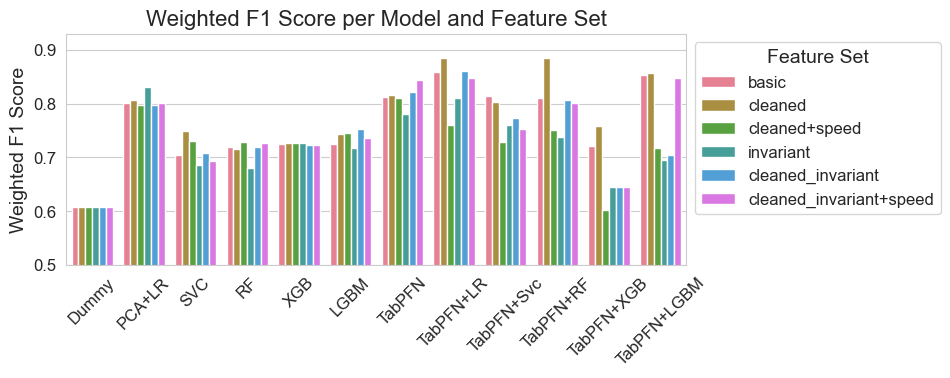

In [116]:
# Mean F1 Score Comparison by Model and Feature Set
fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "weighted_f1").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    hue_order=feature_set_order,
    order=MODEL_ORDER,
    ax=ax,
    errorbar=None,
)
ax.set_ylabel("Weighted F1 Score", fontsize=14)
ax.set_xlabel("")

ax.set_title("Weighted F1 Score per Model and Feature Set", fontsize=16)
ax.legend(
    title="Feature Set", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12, title_fontsize=14
)
ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylim(0.5, None)

plt.savefig(ROOT_DIR / "plots" / f"{LOGO_GROUP}_f1_comparison.pdf", bbox_inches="tight")

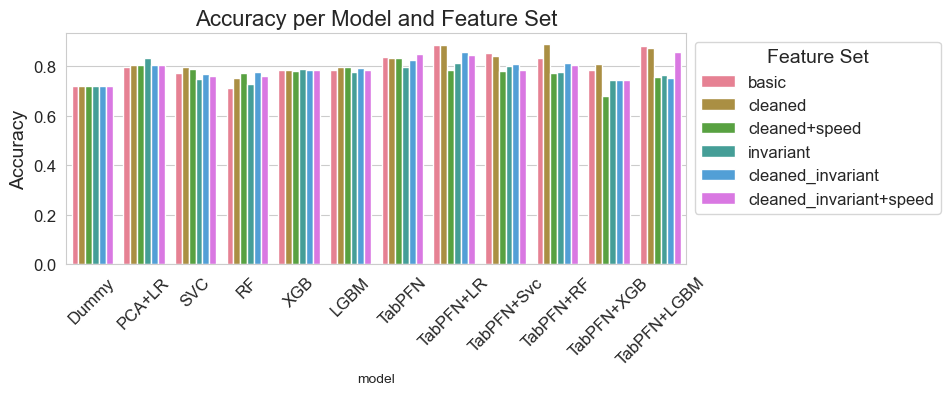

In [112]:
# Mean Accuracy Comparison by Model and Feature Set
fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "accuracy").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    hue_order=feature_set_order,
    order=MODEL_ORDER,
    ax=ax,
    errorbar=None,
)
ax.set_ylabel("Accuracy", fontsize=14)
ax.set_title("Accuracy per Model and Feature Set", fontsize=16)
ax.legend(
    title="Feature Set", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12, title_fontsize=14
)
ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.savefig(ROOT_DIR / "plots" / f"{LOGO_GROUP}_accuracy_comparison.pdf", bbox_inches="tight")

### Feature Set Wins

In [53]:
models_name_mapping = {
    "log_reg": "PCA+LR",
    "svc": "SVC",
    "rf": "RF",
    "xgb": "XGB",
    "lgbm": "LGBM",
    "tabpfn": "TabPFN",
    "tabpfn_emb_lgbm": "TabPFN+LGBM",
    "tabpfn_emb_svc": "TabPFN+SVC",
    "tabpfn_emb_xgb": "TabPFN+XGB",
    "tabpfn_emb_log_reg": "TabPFN+PCA+LR",
    "tabpfn_emb_rf": "TabPFN+RF",
}
models = list(models_name_mapping.keys())

res = []
for model in models:
    model_df = pl.read_csv(ROOT_DIR / "results" / f"{model}_logo_{LOGO_GROUP}_results.csv")
    model_df = (
        model_df.group_by(pl.col("^param_.*$").exclude("param_feature_selector__feature_set"))
        .agg([pl.col("param_feature_selector__feature_set"), pl.col("mean_test_weighted_f1")])
        .with_columns(
            # Find the max f1 score in each group
            pl.col("mean_test_weighted_f1").list.max().alias("max_f1")
        )
        .explode(["param_feature_selector__feature_set", "mean_test_weighted_f1"])
        .with_columns(
            # Mark winners (feature sets with the max f1 score)
            (pl.col("mean_test_weighted_f1") == pl.col("max_f1")).alias("is_winner")
        )
        .filter(pl.col("is_winner"))
        .group_by("param_feature_selector__feature_set")
        .agg(pl.len().alias("wins"))
        .with_columns(pl.lit(model).alias("model"))
    )
    res.append(model_df)
final_df = pl.concat(res).with_columns(
    pl.col("model").replace_strict(models_name_mapping).alias("model")
)
final_df

param_feature_selector__feature_set,wins,model
str,u32,str
"""invariant""",38,"""PCA+LR"""
"""basic""",1,"""PCA+LR"""
"""cleaned+speed""",58,"""PCA+LR"""
"""cleaned_invariant+speed""",58,"""PCA+LR"""
"""cleaned""",47,"""PCA+LR"""
…,…,…
"""cleaned_invariant+speed""",2,"""TabPFN+RF"""
"""cleaned_invariant""",2,"""TabPFN+RF"""
"""cleaned+speed""",2,"""TabPFN+RF"""


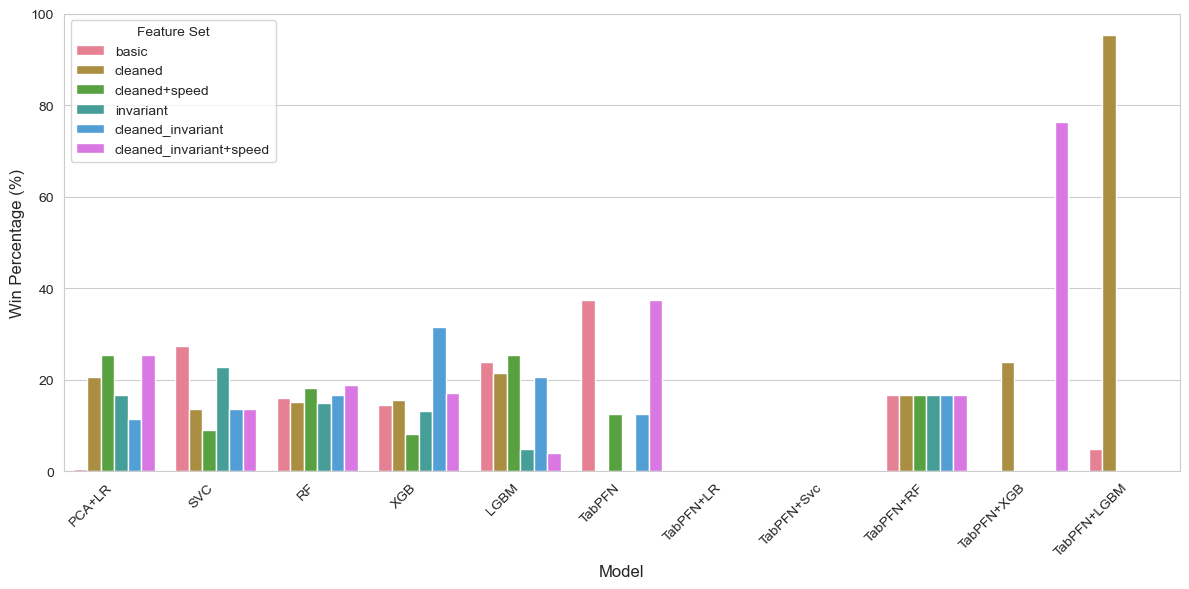

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to proportions within each model
wins_prop = final_df.with_columns(
    pl.col("wins").sum().over("model").alias("total_wins_per_model")
).with_columns((pl.col("wins") / pl.col("total_wins_per_model") * 100).alias("win_percentage"))

# Convert to pandas only for plotting
plot_df = wins_prop.select(
    ["param_feature_selector__feature_set", "model", "win_percentage"]
).to_pandas()

# Create barplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="model",
    y="win_percentage",
    hue="param_feature_selector__feature_set",
    order=MODEL_ORDER[1:],
    hue_order=feature_set_order,
    ax=ax,
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Win Percentage (%)", fontsize=12)
ax.legend(title="Feature Set")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Splitwise Results

In [29]:
# Plot the different splits

best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_weighted_f1$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_acc$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)


all_metrics_split = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(
        pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"),
        pl.col("model").replace_strict(model_name_mapping).alias("model"),
    )
    .with_columns(pl.col("split").replace_strict(idx2name).alias("leave_out_group"))
)

In [30]:
all_metrics_split

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""Dummy""","""basic""",0,0.45,"""weighted_f1""","""ID.4"""
"""XGB""","""invariant""",0,0.45,"""weighted_f1""","""ID.4"""
"""TabPFN""","""cleaned_invariant+speed""",0,0.728571,"""weighted_f1""","""ID.4"""
"""TabPFN+LGBM""","""cleaned""",0,0.780952,"""weighted_f1""","""ID.4"""
"""RF""","""cleaned+speed""",0,0.534266,"""weighted_f1""","""ID.4"""
…,…,…,…,…,…
"""TabPFN""","""cleaned_invariant+speed""",3,0.851852,"""accuracy""","""E-Golf"""
"""RF""","""cleaned+speed""",3,0.703704,"""accuracy""","""E-Golf"""
"""LGBM""","""cleaned_invariant""",3,0.740741,"""accuracy""","""E-Golf"""


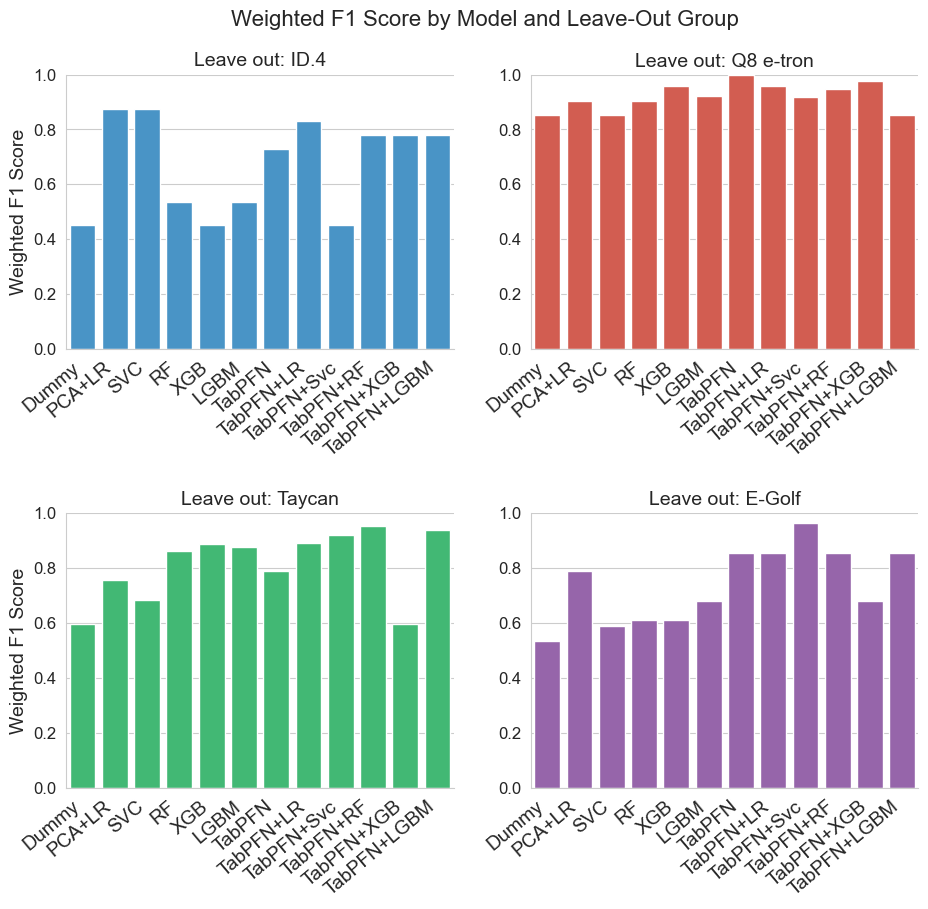

In [91]:
# Weighted F1 Score faceted by Leave-Out Group
plot_data = all_metrics_split.filter(pl.col("metric") == "weighted_f1")

g = sns.catplot(
    data=plot_data.to_pandas(),
    x="model",
    y="score",
    col="leave_out_group",
    col_order=SPLIT_ORDER,
    order=MODEL_ORDER,
    kind="bar",
    height=4,
    aspect=1.2,
    hue="leave_out_group",
    palette=SPLIT_PALETTE,
    col_wrap=2,
    legend=False,
    sharex=False,
    sharey=False,
)

g.set_axis_labels("", "Weighted F1 Score", fontsize=14)
g.set_titles("Leave out: {col_name}", fontsize=16)

for ax in g.axes.flat:
    ax.set_ylim(top=1)
    ax.tick_params(axis="x", rotation=40, labelsize=14)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_title(ax.get_title(), fontsize=14)
    for label in ax.get_xticklabels():
        label.set_ha("right")

g.figure.subplots_adjust(hspace=0.6, wspace=0.2)
plt.suptitle("Weighted F1 Score by Model and Leave-Out Group", fontsize=16, y=1.04)
plt.savefig(ROOT_DIR / "plots" / f"{LOGO_GROUP}_f1_splits_comparison.pdf", bbox_inches="tight")

In [ ]:
res_per_fold = plot_data.group_by("leave_out_group").agg(
    pl.col("score").mean().alias("mean_score"), pl.col("score").std().alias("std_score")
)

In [96]:
print(res_per_fold)

shape: (4, 3)
┌─────────────────┬────────────┬───────────┐
│ leave_out_group ┆ mean_score ┆ std_score │
│ ---             ┆ ---        ┆ ---       │
│ str             ┆ f64        ┆ f64       │
╞═════════════════╪════════════╪═══════════╡
│ ID.4            ┆ 0.672425   ┆ 0.173648  │
│ E-Golf          ┆ 0.740084   ┆ 0.138836  │
│ Taycan          ┆ 0.812618   ┆ 0.128594  │
│ Q8 e-tron       ┆ 0.920157   ┆ 0.050622  │
└─────────────────┴────────────┴───────────┘
